# Spam Classification using AdaBoosting
### Step by step — one task per cell

In [70]:
# Step 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [71]:
# Step 2 - Load the dataset
df = pd.read_csv('spam_data.csv')
df.head()

,email_id,date,subject,body_preview,word_count,num_links,num_exclamations,capital_ratio,special_char_ratio,has_html,email_length,sender_score,label
0,EML05269,6/1/2020,New feature release,r h c i o c z l schedule u o t s v k f k forwa...,30,0,9,0.10,0.3667,True,79.0,83.42,ham
1,EML03462,4/2/2022,Your order has shipped,update t k n y t agenda p r h n m n discuss y ...,130,0,10,0.02,0.2154,false,316.0,18.71,no
2,EML00655,NaN,Click here to claim prize,s m e f b h a l e a o v g f b a o l q o v y l ...,195,4,24,0.46,0.0205,False,451.0,58.18,1
3,EML04616,5/10/2020,Book club meeting,z thanks s v a e v u h o f f s i i d q m team ...,23,0,18,0.02,0.7391,False,53.0,87.66,ham
4,EML04645,4.2.2024,Meeting tomorrow at 3pm,u n p e v r s w p c b r n v r b y p h o best f...,153words,1,2,0.19,0.0131,True,343.0,26.33,HAM


In [72]:
# Step 3 - Check shape and data types
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (5650, 13)

email_id                  str
date                      str
subject                   str
body_preview              str
word_count                str
num_links               int64
num_exclamations        int64
capital_ratio         float64
special_char_ratio        str
has_html                  str
email_length          float64
sender_score          float64
label                     str
dtype: object


In [73]:
# Step 4 - Check missing values
df.isnull().sum()

email_id                 0
date                  1070
subject                 88
body_preview             0
word_count               0
num_links                0
num_exclamations         0
capital_ratio            0
special_char_ratio       0
has_html                91
email_length           335
sender_score           484
label                    0
dtype: int64

In [74]:
# Step 5 - Check unique label values (messy labels)
df['label'].value_counts()

label
ham      374
 ham     368
NO       363
no       358
Ham      354
No       332
HAM      330
ham      324
0        312
YES      297
Yes      296
1        293
SPAM     291
spam     290
Spam     287
spam     263
 spam    259
yes      259
Name: count, dtype: int64

In [75]:
# Step 6 - Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 150


In [76]:
# Step 7 - Drop duplicate rows
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5500, 13)


In [77]:
# Step 8 - Fix label column (standardise to 0 and 1)
spam_vals = {'spam', '1', 'yes'}

def fix_label(val):
    v = str(val).strip().lower()
    return 1 if v in spam_vals else 0

df['label'] = df['label'].apply(fix_label)
print(df['label'].value_counts())

label
0    3035
1    2465
Name: count, dtype: int64


In [78]:
df['word_count'].head()

0          30
1         130
2         195
3          23
4    153words
Name: word_count, dtype: str

In [79]:
# Step 9 - Fix word_count column (remove "words" suffix and convert to number)
df['word_count'] = df['word_count'].astype(str).str.replace('words', '').str.strip()
df['word_count'] = pd.to_numeric(df['word_count'], errors='coerce')
print(df['word_count'].dtype)
df['word_count'].head()

int64


0     30
1    130
2    195
3     23
4    153
Name: word_count, dtype: int64

In [80]:
# Step 10 - Fix special_char_ratio column (remove "%" and convert to number)
df['special_char_ratio'] = df['special_char_ratio'].astype(str).str.replace('%', '').str.strip()
df['special_char_ratio'] = pd.to_numeric(df['special_char_ratio'], errors='coerce')
df['special_char_ratio'] = df['special_char_ratio'].clip(upper=1.0)
print(df['special_char_ratio'].dtype)
df['special_char_ratio'].head()

float64


0    0.3667
1    0.2154
2    0.0205
3    0.7391
4    0.0131
Name: special_char_ratio, dtype: float64

In [81]:
# Step 11 - Fix has_html column (convert to 0 and 1)
true_vals = {'true', '1', 'yes'}

def fix_bool(val):
    if pd.isna(val):
        return np.nan
    return 1 if str(val).strip().lower() in true_vals else 0

df['has_html'] = df['has_html'].apply(fix_bool)
print(df['has_html'].value_counts(dropna=False))

has_html
1.0    3174
0.0    2237
NaN      89
Name: count, dtype: int64


In [82]:
# Step 12 - Fix sender_score (clip outliers to 0-100 range)
df['sender_score'] = pd.to_numeric(df['sender_score'], errors='coerce')
df['sender_score'] = df['sender_score'].clip(lower=0, upper=100)
print(df['sender_score'].describe())

count    5029.000000
mean       50.209207
std        30.528972
min         0.000000
25%        24.070000
50%        50.610000
75%        76.450000
max       100.000000
Name: sender_score, dtype: float64


In [83]:
# Step 13 - Fix num_exclamations (remove negative values)
df['num_exclamations'] = df['num_exclamations'].abs()
print(df['num_exclamations'].describe())

count    5500.000000
mean       17.542182
std        13.297163
min         0.000000
25%         7.000000
50%        14.000000
75%        24.000000
max        50.000000
Name: num_exclamations, dtype: float64


In [84]:
# Step 14 - Fill missing values with column median
num_cols = ['word_count', 'num_links', 'num_exclamations',
            'capital_ratio', 'special_char_ratio',
            'has_html', 'email_length', 'sender_score']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values after cleaning:")
print(df[num_cols].isnull().sum())

Missing values after cleaning:
word_count              0
num_links               0
num_exclamations        0
capital_ratio           0
special_char_ratio      0
has_html               89
email_length          329
sender_score          471
dtype: int64


In [85]:
# Step 15 - Check cleaned data
print("Final shape:", df.shape)
df[num_cols + ['label']].head()

Final shape: (5500, 13)


,word_count,num_links,num_exclamations,capital_ratio,special_char_ratio,has_html,email_length,sender_score,label
0,30,0,9,0.10,0.3667,1.0,79.0,83.42,0
1,130,0,10,0.02,0.2154,0.0,316.0,18.71,0
2,195,4,24,0.46,0.0205,0.0,451.0,58.18,1
3,23,0,18,0.02,0.7391,0.0,53.0,87.66,0
4,153,1,2,0.19,0.0131,1.0,343.0,26.33,0


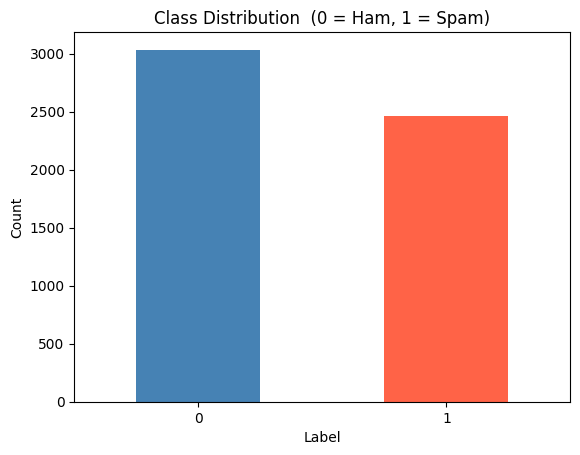

In [86]:
# Step 16 - Plot class distribution
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution  (0 = Ham, 1 = Spam)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

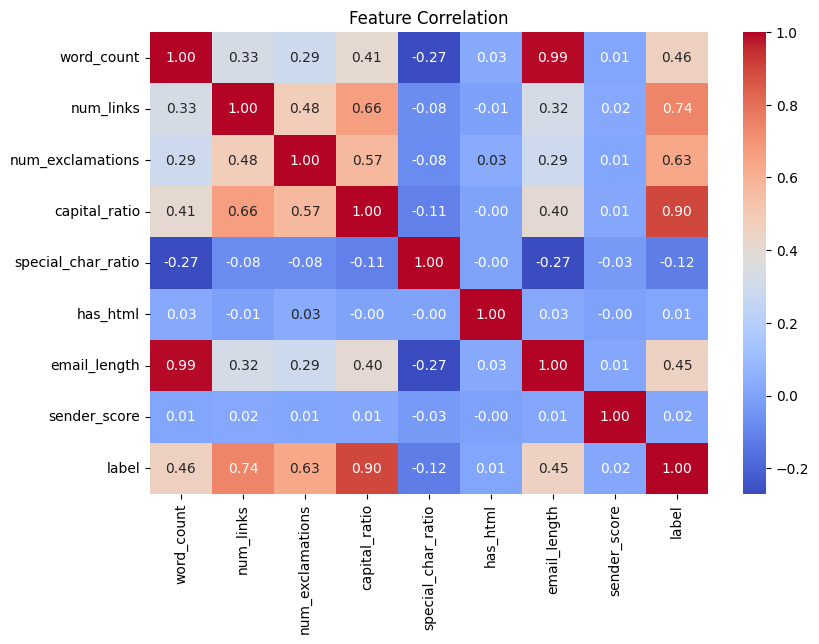

In [87]:
# Step 17 - Correlation heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols + ['label']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [88]:
# Step 18 - Select features and split into train / test
features = ['word_count', 'num_links', 'num_exclamations',
            'capital_ratio', 'special_char_ratio',
            'has_html', 'email_length', 'sender_score']

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))

Training samples: 4400
Testing  samples: 1100


In [89]:
X.head()

,word_count,num_links,num_exclamations,capital_ratio,special_char_ratio,has_html,email_length,sender_score
0,30,0,9,0.10,0.3667,1.0,79.0,83.42
1,130,0,10,0.02,0.2154,0.0,316.0,18.71
2,195,4,24,0.46,0.0205,0.0,451.0,58.18
3,23,0,18,0.02,0.7391,0.0,53.0,87.66
4,153,1,2,0.19,0.0131,1.0,343.0,26.33


In [90]:


# Step 19 - Train AdaBoost model
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

median_values = X_train.median()
X_train = X_train.fillna(median_values)
X_test = X_test.fillna(median_values)

ada.fit(X_train, y_train)
print("Model trained successfully!")
print("Model trained successfully!")

Model trained successfully!
Model trained successfully!


In [91]:
# Step 20 - Make predictions
y_pred = ada.predict(X_test)
print("Predictions done!")
print("Sample predictions:", y_pred[:10])

Predictions done!
Sample predictions: [0 0 0 1 1 0 1 1 1 1]


In [92]:
# Step 21 - Check accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 1.0000


In [93]:
# Step 22 - Classification report
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       607
        Spam       1.00      1.00      1.00       493

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



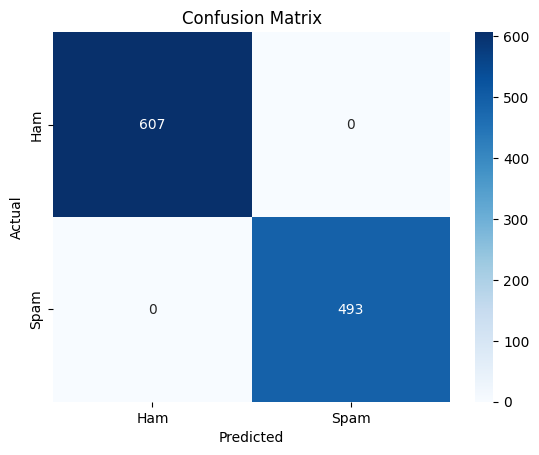

In [94]:
# Step 23 - Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## pickle file

In [ ]:
# Step 25 - Save model to pickle file
import pickle

with open('spam_model.pkl', 'wb') as f:
    pickle.dump(ada, f)

print("Model saved as spam_model.pkl")

In [96]:
with open("piyush.tx",'w') as f:
    f.write("hii this piyush ayush here")

print("File written successfully!")

File written successfully!
